In [12]:
import sys; sys.path.insert(0, "/work/nvme/bbjs/sbharadwaj/powsm/xeuspr")
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.metrics.phone_recognition import PhoneRecognitionEvaluator
from src.recipe.phone_recognition.local.error_analysis_utils import (
    load_dataset_predictions,
    build_utt_dataframe,
    audio_duration,
    annotate_lang_meta,
    load_voxangeles_lang_meta,
    VA_AUDIO_PATTERN,
)

sns.set_theme(style="whitegrid", font_scale=1.15)

# ── Define the two models to compare ─────────────────────────────────────────
MODEL_A = 'xeus_multiaccent.selfctc_l4_8_12.bs240.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000'
MODEL_B = 'huper'

evaluator = PhoneRecognitionEvaluator(normalize_ipa=True)

In [11]:
# ── Reload utils (run after editing error_analysis_utils.py) ─────────────────
import importlib
import src.recipe.phone_recognition.local.error_analysis_utils as _eau
importlib.reload(_eau)
from src.recipe.phone_recognition.local.error_analysis_utils import (
    load_dataset_predictions,
    build_utt_dataframe,
    audio_duration,
    annotate_lang_meta,
    load_voxangeles_lang_meta,
    VA_AUDIO_PATTERN,
)
print('error_analysis_utils reloaded.')

error_analysis_utils reloaded.


In [4]:
# ── Load VoxAngeles predictions for both models ───────────────────────────────
print('=== voxangeles ===')
va_preds = load_dataset_predictions('voxangeles', models=[MODEL_A, MODEL_B])

# ── Build per-utterance DataFrames (one per model) ───────────────────────────
# va_audio = lambda u: audio_duration(u, VA_AUDIO_PATTERN)
va_audio=None
a_name='PhoneticXeus'
b_name='HuPER'

preds_a = {MODEL_A: va_preds[MODEL_A]}
preds_b = {MODEL_B: va_preds[MODEL_B]}

print('\nComputing per-utterance metrics for MODEL_A ...')
df_a = build_utt_dataframe(preds_a, evaluator, audio_fn=va_audio)
df_a['model'] = a_name

print('Computing per-utterance metrics for MODEL_B ...')
df_b = build_utt_dataframe(preds_b, evaluator, audio_fn=va_audio)
df_b['model'] = b_name

print(f'\nMODEL_A: {len(df_a)} utts, mean FER={df_a["fer"].mean():.2f}%')
print(f'MODEL_B: {len(df_b)} utts, mean FER={df_b["fer"].mean():.2f}%')

# Combined long-form DataFrame for faceted plots
df_all = pd.concat([df_a, df_b], ignore_index=True)
df_all.head()

=== voxangeles ===
  xeus_multiaccent.selfctc_l4_8_12.bs240.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000: 5445 utts across 95 lang(s)
  huper: 5445 utts across 95 lang(s)

Computing per-utterance metrics for MODEL_A ...
Computing per-utterance metrics for MODEL_B ...

MODEL_A: 5445 utts, mean FER=14.83%
MODEL_B: 5445 utts, mean FER=28.20%


,utt_id,langcode,langname,reference,predicted,pfer,fer,fed,per,n_phones,duration,model
0,lit-002-067-28,lit,Lithuanian,iːstʲɾʲɪʒʲaɪ,estiriʒɑejestiriʒɑs,11.333333,129.947917,10.395833,225.0,8,None,PhoneticXeus
1,lit-002-069-29,lit,Lithuanian,iispuːdʲɪs,ispudis,1.125000,13.020833,1.041667,50.0,8,None,PhoneticXeus
2,lit-002-070-30,lit,Lithuanian,dʲeːka,dieka,1.083333,25.000000,1.000000,75.0,4,None,PhoneticXeus
3,lit-002-111-31,lit,Lithuanian,tʊɾʲtʲɛ,turta,0.291667,5.416667,0.270833,80.0,5,None,PhoneticXeus
4,lit-002-112-32,lit,Lithuanian,tʊɾtas,torrtas,1.083333,15.972222,0.958333,50.0,6,None,PhoneticXeus


In [5]:
# ── Annotate with language family and macroarea ───────────────────────────────
lang_meta = load_voxangeles_lang_meta()
df_a   = annotate_lang_meta(df_a,   lang_meta)
df_b   = annotate_lang_meta(df_b,   lang_meta)
df_all = annotate_lang_meta(df_all, lang_meta)

print(f"Coverage: {df_a['family'].notna().sum()}/{len(df_a)} utts have family annotation")
print(f"Families : {sorted(df_a['family'].dropna().unique())}")
print(f"Macroareas: {sorted(df_a['macroarea'].dropna().unique())}")
df_all[['langcode', 'family', 'macroarea']].drop_duplicates().sort_values('langcode')

Coverage: 5324/5445 utts have family annotation
Families : ['Abkhaz-Adyge', 'Afro-Asiatic', 'Athabaskan-Eyak-Tlingit', 'Atlantic-Congo', 'Austroasiatic', 'Austronesian', 'Central Sudanic', 'Dravidian', 'Ijoid', 'Indo-European', 'Kakua-Nukak', 'Kru', 'Mande', 'Nakh-Daghestanian', 'Nuclear Torricelli', 'Salishan', 'Sino-Tibetan', 'Siouan', 'Turkic', 'Uralic']
Macroareas: ['Africa', 'Eurasia', 'North America', 'Papunesia', 'South America']


,langcode,family,macroarea
1387,abk,Abkhaz-Adyge,Eurasia
1441,ace,Austronesian,Papunesia
1480,ady,Abkhaz-Adyge,Eurasia
1601,aeb,Afro-Asiatic,Africa
1643,afn,Ijoid,Africa
...,...,...,...
1101,sbc,Austronesian,Papunesia
1124,tsw,Atlantic-Congo,Africa
1150,tzm,Afro-Asiatic,Africa
1190,wuu,Sino-Tibetan,Eurasia


In [6]:
fer_comparison = df_all.groupby(['model', 'family'])['fer'].mean()
fer_comparison = fer_comparison.reset_index().pivot(index='family', columns='model', values='fer').reset_index()
fer_comparison

model,family,HuPER,PhoneticXeus
0,Abkhaz-Adyge,41.882492,25.794435
1,Afro-Asiatic,25.509502,12.353271
2,Athabaskan-Eyak-Tlingit,23.844153,18.874901
3,Atlantic-Congo,27.149998,12.545281
4,Austroasiatic,33.983006,18.164036
5,Austronesian,24.762801,11.011311
6,Central Sudanic,65.851449,44.384058
7,Dravidian,23.885629,14.938705
8,Ijoid,29.825611,10.491743
9,Indo-European,24.808014,12.352518


/tmp/ipykernel_3232218/836083716.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9.5)


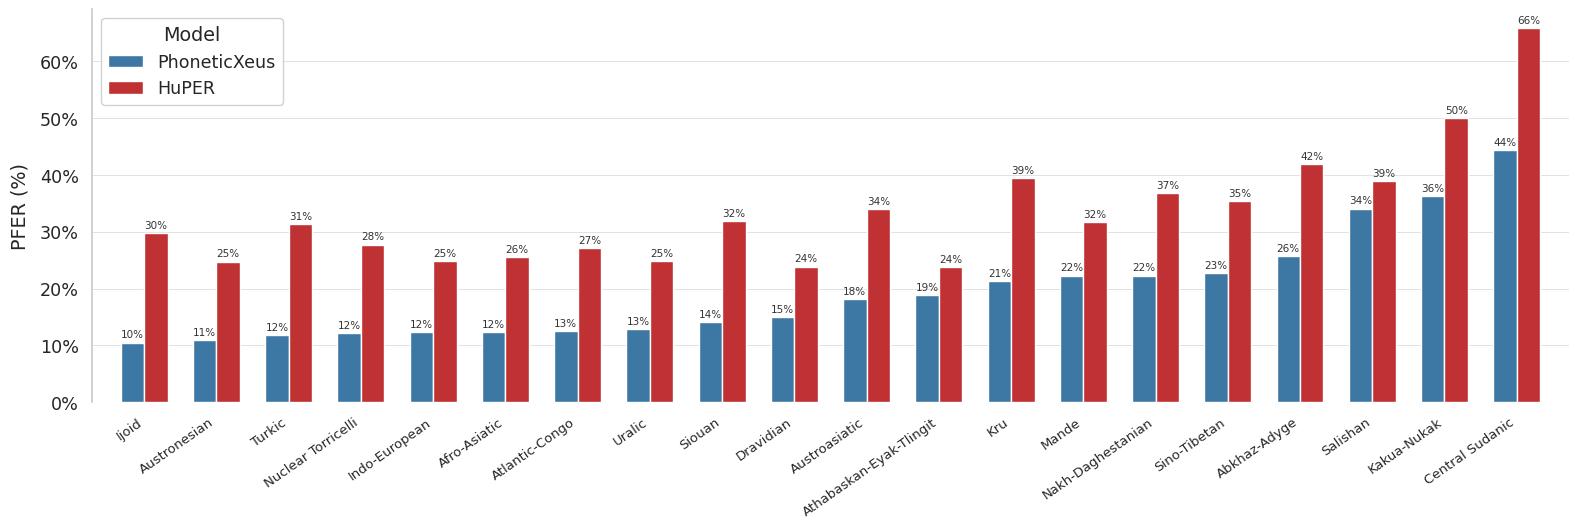

Saved → /work/nvme/bbjs/sbharadwaj/powsm/xeuspr/src/recipe/phone_recognition/local/is26_viz/vox_family.pdf


In [7]:
from pathlib import Path

PALETTE = {a_name: "#2c7bb6", b_name: "#d7191c"}
OUT_DIR = Path("/work/nvme/bbjs/sbharadwaj/powsm/xeuspr/src/recipe/phone_recognition/local/is26_viz")
OUT_DIR.mkdir(exist_ok=True)

# ── melt to long form, sort by MODEL_A FER ascending ─────────────────────────
plot_df = (
    fer_comparison
    .sort_values(a_name)
    .melt(id_vars="family", value_vars=[a_name, b_name],
          var_name="Model", value_name="FER (%)")
)

fig, ax = plt.subplots(figsize=(16, 5.5))

sns.barplot(
    data=plot_df,
    x="family", y="FER (%)",
    hue="Model", palette=PALETTE,
    width=0.65, ax=ax,
)

# value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", fontsize=7.5, padding=2, color="#333333")

ax.yaxis.grid(True, color="#dddddd", linewidth=0.6, linestyle="-")
ax.set_axisbelow(True)

# ax.set_title("PFER by Language Family", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("PFER (%)", labelpad=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9.5)
ax.legend(title="Model", frameon=True, loc="upper left", framealpha=0.9)
ax.margins(x=0.02)
sns.despine(bottom=True)
plt.tight_layout()
plt.savefig(OUT_DIR / "vox_family.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR / 'vox_family.pdf'}")

In [42]:
lang_meta[lang_meta['family']=='Athabaskan-Eyak-Tlingit']

,langcode,family,macroarea
10,apw,Athabaskan-Eyak-Tlingit,North America
200,nav,Athabaskan-Eyak-Tlingit,North America


In [8]:
lang_fer_agg = (
    df_all.groupby(['model', 'langname'])['fer']
    .agg(mean='mean', std='std')
    .reset_index()
)

mean_pivot = lang_fer_agg.pivot(index='langname', columns='model', values='mean').reset_index()
std_pivot  = lang_fer_agg.pivot(index='langname', columns='model', values='std').reset_index()
std_pivot  = std_pivot.rename(columns={a_name: f'{a_name}_std', b_name: f'{b_name}_std'})

lang_fer_comparison = mean_pivot.merge(std_pivot, on='langname')
lang_fer_comparison.columns.name = None
lang_fer_comparison

,langname,HuPER,PhoneticXeus,HuPER_std,PhoneticXeus_std
0,Abkhazian,40.159649,20.586649,45.364720,13.979221
1,Achinese,33.763863,11.810897,20.552532,13.484772
2,Adamawa Fulfulde,20.792572,6.431159,17.491536,10.374689
3,Adyghe,42.651365,28.118571,18.145160,22.171447
4,Afrikaans,24.119064,15.573396,24.615980,17.803812
...,...,...,...,...,...
90,Western Bru,38.651235,23.359568,19.821174,13.655057
91,Wu Chinese,52.244718,40.087050,31.852808,30.507707
92,Yue Chinese,30.970293,12.099041,25.734053,16.347781
93,ajp,21.515912,10.982240,14.660602,10.840976


In [9]:
lang_fer_comparison.sort_values(a_name, ascending=False).head(20)

,langname,HuPER,PhoneticXeus,HuPER_std,PhoneticXeus_std
73,Lendu,65.851449,44.384058,22.444684,34.063295
91,Wu Chinese,52.244718,40.087050,31.852808,30.507707
21,Cacua,50.006994,36.261141,21.438123,28.916746
26,Columbia-Wenatchi,38.928191,34.095978,20.855263,19.052211
3,Adyghe,42.651365,28.118571,18.145160,22.171447
37,Ewe,32.743056,25.667032,18.583582,23.324088
43,Hakka Chinese,28.745412,25.207589,25.026338,29.592886
23,Chamalal,38.447759,24.828756,25.663988,23.981450
14,Bassa,38.761574,23.541667,22.595768,16.596205
90,Western Bru,38.651235,23.359568,19.821174,13.655057


In [20]:
analyze_feature_errors(df_to_entries(df_a.head()))

100%|██████████| 5/5 [00:00<00:00, 12977.43it/s]


{'per_feature': {'tense': {'fer': 0.533, 'errors': 8, 'total': 15},
  'hi': {'fer': 0.276, 'errors': 8, 'total': 29},
  'distr': {'fer': 0.235, 'errors': 4, 'total': 17},
  'ant': {'fer': 0.211, 'errors': 4, 'total': 19},
  'syl': {'fer': 0.133, 'errors': 4, 'total': 30},
  'cons': {'fer': 0.133, 'errors': 4, 'total': 30},
  'cor': {'fer': 0.133, 'errors': 4, 'total': 30},
  'son': {'fer': 0.1, 'errors': 3, 'total': 30},
  'long': {'fer': 0.1, 'errors': 3, 'total': 30},
  'delrel': {'fer': 0.074, 'errors': 2, 'total': 27},
  'lo': {'fer': 0.074, 'errors': 2, 'total': 27},
  'cont': {'fer': 0.067, 'errors': 2, 'total': 30},
  'voi': {'fer': 0.067, 'errors': 2, 'total': 30},
  'back': {'fer': 0.067, 'errors': 2, 'total': 30},
  'strid': {'fer': 0.033, 'errors': 1, 'total': 30},
  'lab': {'fer': 0.033, 'errors': 1, 'total': 30},
  'round': {'fer': 0.033, 'errors': 1, 'total': 30},
  'lat': {'fer': 0.0, 'errors': 0, 'total': 30},
  'nas': {'fer': 0.0, 'errors': 0, 'total': 30},
  'sg': {'f

Computing feature errors for PhoneticXeus ...


100%|██████████| 100/100 [00:00<00:00, 17575.13it/s]


Computing feature errors for HuPER ...


100%|██████████| 100/100 [00:00<00:00, 42315.42it/s]



Top 7 features by count: [('Syllabic', 568), ('Consonantal', 568), ('Back', 568), ('Coronal', 568), ('Labial', 568), ('Sonorant', 568), ('Continuant', 568)]


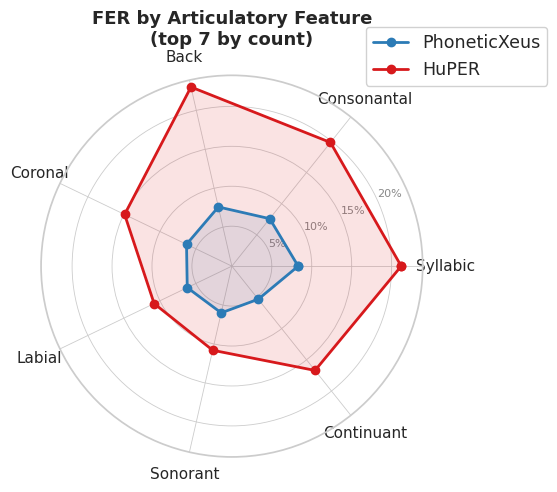

Saved → /work/nvme/bbjs/sbharadwaj/powsm/xeuspr/src/recipe/phone_recognition/local/is26_viz/vox_spider.pdf


In [21]:
from src.recipe.phone_recognition.local.error_analysis_utils import (
    df_to_entries, analyze_feature_errors,
)

FEAT_DISPLAY = {
    "syl":    "Syllabic",   "son":    "Sonorant",    "cons":   "Consonantal",
    "cont":   "Continuant", "delrel": "Del. Release", "lat":    "Lateral",
    "nas":    "Nasal",      "strid":  "Strident",     "voi":    "Voicing",
    "sg":     "Spread Gl.", "cg":     "Constr. Gl.",  "ant":    "Anterior",
    "cor":    "Coronal",    "distr":  "Distributed",  "lab":    "Labial",
    "hi":     "High",       "lo":     "Low",           "back":   "Back",
    "round":  "Round",      "tense":  "Tense",         "long":   "Long",
}

# ── Compute per-feature FER (slow: runs panphon on all substitutions) ─────────
NSAMPLES=100
print("Computing feature errors for", a_name, "...")
feat_a = analyze_feature_errors(df_to_entries(df_a.head(NSAMPLES)))["per_feature"]
print("Computing feature errors for", b_name, "...")
feat_b = analyze_feature_errors(df_to_entries(df_b.head(NSAMPLES)))["per_feature"]

# ── Top 7 features by count (most data → most reliable estimate) ──────────────
top7 = sorted(
    [f for f in feat_a if feat_a[f]["total"] > 0],
    key=lambda f: -feat_a[f]["total"],
)[:7]

labels = [FEAT_DISPLAY.get(f, f) for f in top7]
vals_a = [feat_a[f]["fer"] * 100 for f in top7]
vals_b = [feat_b[f]["fer"] * 100 for f in top7]

print(f"\nTop 7 features by count: {list(zip(labels, [feat_a[f]['total'] for f in top7]))}")

# ── Spider chart ──────────────────────────────────────────────────────────────
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for vals, name, color in [
    (vals_a, a_name, PALETTE[a_name]),
    (vals_b, b_name, PALETTE[b_name]),
]:
    v = vals + vals[:1]
    ax.plot(angles, v, "o-", linewidth=2, color=color, label=name, zorder=3)
    ax.fill(angles, v, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_rlabel_position(25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.tick_params(axis="y", labelsize=8, labelcolor="#888888")
ax.grid(color="#cccccc", linewidth=0.6)
ax.spines["polar"].set_color("#cccccc")
ax.set_title(
    "FER by Articulatory Feature\n(top 7 by count)",
    fontsize=13, fontweight="bold", pad=22,
)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUT_DIR / "vox_spider.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR / 'vox_spider.pdf'}")

In [ ]:
# ── Load GMUAccent predictions for both models ────────────────────────────────
print('=== gmuaccent ===')
gmu_preds = load_dataset_predictions('gmuaccent', models=[MODEL_A, MODEL_B])

gmu_preds_a = {MODEL_A: gmu_preds[MODEL_A]}
gmu_preds_b = {MODEL_B: gmu_preds[MODEL_B]}

print('\nComputing per-utterance metrics for MODEL_A ...')
df_gmu_a = build_utt_dataframe(gmu_preds_a, evaluator, audio_fn=None)
df_gmu_a['model'] = a_name

print('Computing per-utterance metrics for MODEL_B ...')
df_gmu_b = build_utt_dataframe(gmu_preds_b, evaluator, audio_fn=None)
df_gmu_b['model'] = b_name

df_gmu_all = pd.concat([df_gmu_a, df_gmu_b], ignore_index=True)
print(f'\nMODEL_A: {len(df_gmu_a)} utts, mean FER={df_gmu_a["fer"].mean():.2f}%')
print(f'MODEL_B: {len(df_gmu_b)} utts, mean FER={df_gmu_b["fer"].mean():.2f}%')
df_gmu_all.head()

In [ ]:
from src.recipe.phone_recognition.local.error_analysis_utils import (
    df_to_entries, analyze_accent_variance,
)

MIN_UTTS = 4   # minimum utterances per accent for stable pairwise estimates

print(f'Computing accent variance for {a_name} ...')
av_a = analyze_accent_variance(df_to_entries(df_gmu_a))['within_language']
print(f'Computing accent variance for {b_name} ...')
av_b = analyze_accent_variance(df_to_entries(df_gmu_b))['within_language']

# ── Build per-accent comparison DataFrame ─────────────────────────────────────
accents = sorted(set(av_a) & set(av_b))
rows = []
for acc in accents:
    n = av_a[acc]['n_speakers']
    if n < MIN_UTTS:
        continue
    rows.append({
        'accent':        acc,
        'n':             n,
        'ref_var':       av_a[acc]['ref_variation'],   # same reference for both models
        f'{a_name}':     av_a[acc]['pred_variation'],
        f'{b_name}':     av_b[acc]['pred_variation'],
        f'{a_name}_ratio': av_a[acc]['ratio'],
        f'{b_name}_ratio': av_b[acc]['ratio'],
    })

gmu_var_df = pd.DataFrame(rows).sort_values(a_name, ascending=False).reset_index(drop=True)
print(f'\n{len(gmu_var_df)} accents with ≥{MIN_UTTS} utterances')
gmu_var_df.head(10)

In [ ]:
# ── Scatter: per-accent pred_variation — MODEL_A vs MODEL_B ──────────────────
# Points on the diagonal → equal variance; above → B more varied; below → A more varied
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    gmu_var_df[a_name], gmu_var_df[b_name],
    c=gmu_var_df['ref_var'], cmap='YlOrRd',
    s=gmu_var_df['n'] * 8, alpha=0.8, edgecolors='#555', linewidths=0.4, zorder=3,
)

# Diagonal reference line (equal variance)
lim_max = max(gmu_var_df[[a_name, b_name]].max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], '--', color='#aaaaaa', linewidth=1.2, zorder=1)

# Colorbar for reference variation
cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cb.set_label('Reference variation', fontsize=9)

# Label notable accents (high ref_var or large gap between models)
gmu_var_df['gap'] = (gmu_var_df[b_name] - gmu_var_df[a_name]).abs()
for _, row in gmu_var_df.nlargest(8, 'ref_var').iterrows():
    ax.annotate(
        row['accent'].replace('_', ' '),
        (row[a_name], row[b_name]),
        fontsize=7.5, xytext=(4, 4), textcoords='offset points', color='#333',
    )

ax.set_xlabel(f'{a_name}  prediction variation', labelpad=8)
ax.set_ylabel(f'{b_name}  prediction variation', labelpad=8)
ax.set_title('Per-accent output variance comparison\n(GMUAccent, dot size ∝ N utts, colour = ref variation)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.grid(color='#e0e0e0', linewidth=0.6)
sns.despine()
plt.tight_layout()
plt.savefig(OUT_DIR / 'gmu_accent_variance.pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR / 'gmu_accent_variance.pdf'}")